# Mendoza Reporta — Fase 2: Optimización Textual y Normalización Léxica

## Objetivo
Evaluar el efecto de mejorar exclusivamente el componente de lenguaje natural del sistema, manteniendo sin cambios la lógica secuencial y los umbrales del filtro visual de la Fase 1 ("Texto OR Imagen").

## Cambios respecto de la Fase 1
1. **Normalización léxica** mediante expresiones regulares, aplicada antes de calcular la similitud de texto: corrige abreviaturas comunes (`q`→`que`, `x`→`por`, `d`→`de`, `xq`→`porque`, `tb`→`también`) y errores ortográficos frecuentes (`zemaforo`→`semáforo`, `vache`→`bache`, `crter`→`cráter`, `ranpa`→`rampa`), y colapsa repeticiones de letras (`sucioooo`→`sucio`) **después** de aplicar las correcciones puntuales, para no destruir patrones que dependen de la repetición (por ejemplo, `rrttto`→`roto`).
2. **Refinamiento del mapa semántico de anclas** por categoría, con énfasis en *Agua y Cloacas* (anclas reformuladas: `agua potable`, `caño maestro`, `pérdida de agua`, `alcantarilla hundida`, `desborde cloacal`, `olor podrido`) y la incorporación de `puente roto`, `zanja` (Acequias y Drenajes) y `rompe cubiertas` (Baches y Pavimentación).

## Dataset
714 elementos (588 reportes válidos y 126 descartes) construidos específicamente para esta evaluación. Las imágenes se obtuvieron mediante búsqueda automatizada de fotografías públicas, organizadas por categoría de infraestructura urbana. Los textos que acompañan a cada imagen son sintéticos, generados de forma programática para cubrir distintos registros de redacción (claro, indirecto, formal, vago) y niveles de ruido ortográfico/tipográfico (ninguno, leve, medio, fuerte), evitando que el motor de texto pueda resolver la tarea por simple coincidencia literal con el mapa semántico. El detalle de la construcción se documenta en el Anexo A que acompaña a este trabajo.

In [7]:
from google.colab import drive
import os

drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/validation_dataset"
os.makedirs(BASE_DIR, exist_ok=True)
print(f"Directorio base configurado: {BASE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directorio base configurado: /content/drive/MyDrive/validation_dataset


In [2]:
!pip install sentence-transformers transformers pillow numpy pandas matplotlib seaborn scikit-learn tqdm

In [3]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from sentence_transformers import SentenceTransformer, util
import pandas as pd
import numpy as np
import math
import json
import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
class CategoryClassifierService:
    def __init__(self):
        self.model = SentenceTransformer('hiiamsid/sentence_similarity_spanish_es').to(device)
        self.semantic_map = {
            "Acequias y Drenajes": ["acequia", "drenaje", "canal", "cuneta", "agua estancada", "puente roto", "zanja"],
            "Alumbrado Público": ["alumbrado", "luz", "poste", "luminaria", "oscuridad", "foco quemado", "farol"],
            "Arbolado Público": ["árbol", "rama", "raíces", "poda", "caído", "tronco", "hojas secas"],
            "Baches y Pavimentación": ["bache", "pozo", "pavimento", "asfalto", "calle rota", "cráter", "hueco", "rompe cubiertas"],
            "Limpieza y Residuos": ["basura", "limpieza", "residuos", "escombros", "mugre", "basural", "suciedad"],
            "Plazas y Parques": ["plaza", "parque", "juegos", "banco", "espacio verde", "columpio", "pasto alto"],
            "Semáforos y Señalización": ["semáforo", "señalización", "cartel", "cruce", "rojo", "indicador", "pare"],
            "Veredas y Accesibilidad": ["vereda", "accesibilidad", "rampa", "baldosa", "peatón", "rotura", "escalón"],
            "Agua y Cloacas": ["agua potable", "cloaca", "caño maestro", "pérdida de agua", "alcantarilla hundida", "desborde cloacal", "olor podrido"],
        }
        self.categories = list(self.semantic_map.keys())

        corpus_sentences = []
        self.corpus_labels = []
        for category, phrases in self.semantic_map.items():
            for phrase in phrases:
                corpus_sentences.append(phrase)
                self.corpus_labels.append(category)

        self.corpus_embeddings = self.model.encode(corpus_sentences, convert_to_tensor=True, normalize_embeddings=True)


    def normalize_text(self, text: str) -> str:
        import re
        t = str(text).lower()
        replacements = [
            (r'\bq\b', 'que'), (r'\bx\b', 'por'), (r'\bd\b', 'de'),
            (r'\b(tb|tbn)\b', 'también'), (r'\b(xq|xque)\b', 'porque'),
            (r'\b(vachhe|bacheazo|vache)\b', 'bache'), (r'\b(crter)\b', 'cráter'),
            (r'\balluda\b', 'ayuda'), (r'\b(zemaforo|semaforo)\b', 'semáforo'),
            (r'\b(ranpa)\b', 'rampa'), (r'\b(rrt+o|rrtto|rto)\b', 'roto')
        ]
        for pattern, repl in replacements:
            t = re.sub(pattern, repl, t)
        # Colapsar letras repetidas (holaaaa -> hola) DESPUES de las correcciones puntuales,
        # para no destruir patrones como 'rrttto' antes de poder corregirlos.
        t = re.sub(r'([a-zA-Z])\1{2,}', r'\1', t)
        return t

    def classify_text(self, description: str) -> dict:
        normalized = self.normalize_text(description)
        query_embedding = self.model.encode(normalized, convert_to_tensor=True, normalize_embeddings=True)
        hits = util.semantic_search(query_embedding, self.corpus_embeddings, top_k=10)[0]

        category_scores = {cat: 0.0 for cat in self.categories}
        for hit in hits:
            cat = self.corpus_labels[hit['corpus_id']]
            if hit['score'] > category_scores[cat]:
                category_scores[cat] = hit['score']
        return category_scores

class ClipService:
    def __init__(self):
        self.model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
        self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        self.real_photo_labels = ["a real photograph of an outdoor urban environment", "a digital illustration, drawing, or meme"]
        self.outdoor_labels = ["an outdoor urban street scene in a city", "an indoor scene, a person, a pet, food or a natural landscape"]
        self.problem_labels = [
            "a blocked or flooded drainage ditch or canal on the street",
            "a broken or unlit streetlight or fallen electric pole",
            "a fallen tree, dangerous branches or roots lifting the sidewalk",
            "a pothole, damaged pavement or broken road surface",
            "garbage, waste, rubble or trash accumulated on the street",
            "a damaged bench, broken playground or neglected public park",
            "a broken traffic light, fallen road sign or faded road markings",
            "a broken sidewalk, missing tiles or blocked pedestrian access",
            "a water leak, broken pipe or overflowing sewer on the street",
            "a normal street or public space in good condition with no issues",
            "an unrelated scene with no urban infrastructure problems visible",
        ]
        self.label_to_category = {
            self.problem_labels[0]: "Acequias y Drenajes",
            self.problem_labels[1]: "Alumbrado Público",
            self.problem_labels[2]: "Arbolado Público",
            self.problem_labels[3]: "Baches y Pavimentación",
            self.problem_labels[4]: "Limpieza y Residuos",
            self.problem_labels[5]: "Plazas y Parques",
            self.problem_labels[6]: "Semáforos y Señalización",
            self.problem_labels[7]: "Veredas y Accesibilidad",
            self.problem_labels[8]: "Agua y Cloacas",
        }
        self.no_problem_labels = {self.problem_labels[9], self.problem_labels[10]}

        self.REAL_PHOTO_THRESHOLD = 0.65
        self.OUTDOOR_THRESHOLD    = 0.60
        self.PROBLEM_THRESHOLD    = 0.40

        self._real_photo_text = self._tokenize_labels(self.real_photo_labels)
        self._outdoor_text    = self._tokenize_labels(self.outdoor_labels)
        self._problem_text    = self._tokenize_labels(self.problem_labels)

    def _tokenize_labels(self, labels):
        return self.processor(text=labels, return_tensors="pt", padding=True)

    def _get_probs(self, image, labels, text_inputs):
        image_inputs = self.processor(images=image, return_tensors="pt")
        inputs = {**image_inputs, **text_inputs}
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = self.model(**inputs)
        logits_per_image = outputs.logits_per_image
        probs = logits_per_image.softmax(dim=1).cpu().numpy()[0]
        return dict(zip(labels, probs))

    def classify_image(self, image) -> dict:
        real_probs = self._get_probs(image, self.real_photo_labels, self._real_photo_text)
        if real_probs[self.real_photo_labels[0]] < self.REAL_PHOTO_THRESHOLD:
            return {"valid": False, "rejection_reason": "not_real_photo", "suggested_category": None}

        outdoor_probs = self._get_probs(image, self.outdoor_labels, self._outdoor_text)
        if outdoor_probs[self.outdoor_labels[0]] < self.OUTDOOR_THRESHOLD:
            return {"valid": False, "rejection_reason": "not_outdoor_urban", "suggested_category": None}

        problem_probs = self._get_probs(image, self.problem_labels, self._problem_text)
        problem_scores = {k: v for k, v in problem_probs.items() if k not in self.no_problem_labels}
        best_label = max(problem_scores, key=problem_scores.get)
        best_score = problem_scores[best_label]

        if best_score < self.PROBLEM_THRESHOLD:
            return {
                "valid": False,
                "rejection_reason": "no_problem_detected",
                "suggested_category": self.label_to_category.get(best_label),
            }

        return {
            "valid": True,
            "suggested_category": self.label_to_category.get(best_label),
            "confidence": best_score,
        }

class ReportDecisionService:
    def __init__(self, text_threshold=0.45):
        self.text_threshold = text_threshold

    def get_best_text_category(self, scores: dict) -> dict:
        if not scores:
            return {"category": None, "confidence": 0, "valid": False}
        best_category = max(scores, key=scores.get)
        best_score = scores[best_category]
        if best_score >= self.text_threshold:
            return {"category": best_category, "confidence": best_score, "valid": True}
        return {"category": None, "confidence": best_score, "valid": False}

print("Modelos Base inicializados.")
text_service = CategoryClassifierService()
clip_service = ClipService()
decision_service = ReportDecisionService(text_threshold=0.45)

Modelos Base inicializados.


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.51k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [5]:
# Test unitario del normalizador (no requiere modelos)
casos_norm = {
    "el zemaforo d la principal ta rrttto": ["semáforo", "roto"],
    "tremendo bacheazo": ["bache"],
    "hay un vache q rompe todo": ["bache", "que"],
    "muy sucioooo todo": ["sucio"],
}
for t, esperados in casos_norm.items():
    salida = CategoryClassifierService.normalize_text(None, t)
    assert all(e in salida for e in esperados), (t, salida, esperados)
    print(f"OK: {t!r} -> {salida!r}")


OK: 'el zemaforo d la principal ta rrttto' -> 'el semáforo de la principal ta roto'
OK: 'tremendo bacheazo' -> 'tremendo bache'
OK: 'hay un vache q rompe todo' -> 'hay un bache que rompe todo'
OK: 'muy sucioooo todo' -> 'muy sucio todo'


In [8]:
def cargar_dataset():
    ruta = os.path.join(BASE_DIR, "real_dataset.json")
    with open(ruta, "r", encoding="utf-8") as f:
        dataset = json.load(f)

    for i, item in enumerate(dataset):
        item["description"] = item.get("description", item.get("text", ""))
    return dataset

dataset_real = cargar_dataset()
print(f"Cargadas {len(dataset_real)} muestras.")

Cargadas 714 muestras.


In [9]:
# ---- Utilidades comunes de evaluación ----
# Intervalo de confianza de Wilson para proporciones, y un reporte de métricas que separa
# explícitamente los errores por rechazo del filtro visual de las confusiones de categoría.
import re, math, collections
import numpy as np
import pandas as pd

def wilson(k, n, z=1.96):
    """Intervalo de confianza de Wilson para una proporción k/n."""
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    den = 1 + z * z / n
    centro = (p + z * z / (2 * n)) / den
    marg = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return (centro - marg, centro + marg)

def fmt_ci(k, n):
    if n == 0:
        return "n/d"
    lo, hi = wilson(k, n)
    return f"{k}/{n} = {k/n*100:.1f}%  (IC95% {lo*100:.1f}-{hi*100:.1f}%)"

def auditar_dataset(ds):
    print(f"Total de muestras: {len(ds)}")
    por_subset = collections.defaultdict(list)
    for it in ds:
        por_subset[it.get("subset", "?")].append(it["description"])
    for s, tx in por_subset.items():
        print(f"  - {s}: {len(tx)} muestras, {len(set(tx))} textos distintos")
    patron_ruido = re.compile(r"\b(q|xq|xque|tb|tbn|d|x)\b|(.)\2{2,}|\b(zemaforo|vache|vachhe|crter|ranpa|rrttto)\b")
    ruidosos = [it["description"] for it in ds if patron_ruido.search(it["description"].lower())]
    print(f"Textos con ruido tipo celular/ortografia: {len(ruidosos)}")
    if not ruidosos:
        print("  AVISO: ningun texto tiene ruido; el normalizador lexico NO se ejerce en esta evaluacion.")
    print("Muestras por categoria:", dict(collections.Counter(it["expected_category"] for it in ds)))

def reportar_metricas(df):
    """Metricas correctamente nombradas, con IC95% y desglose rechazo vs confusion."""
    val = df[~df["es_descarte"]]
    des = df[df["es_descarte"]]
    k_v, n_v = int(val["acierto"].sum()), len(val)
    rech = int((val["prediccion"] == "RECHAZADO_ERROR").sum())
    conf = n_v - k_v - rech
    print("=== Reportes VALIDOS ===")
    print("Accuracy de punta a punta (categoria correcta / todos los validos):", fmt_ci(k_v, n_v))
    print(f"  Errores por rechazo (bloqueados por CLIP/filtros): {rech} ({rech/n_v*100:.1f}%)")
    print(f"  Errores por confusion de categoria:               {conf} ({conf/n_v*100:.1f}%)")
    k_d, n_d = int(des["acierto"].sum()), len(des)
    print("=== DESCARTES ===")
    print("Tasa de rechazo correcto (TNR):", fmt_ci(k_d, n_d))
    print("\nAccuracy por categoria (validos):")
    tabla = val.groupby("esperado")["acierto"].agg(["sum", "count", "mean"])
    tabla.columns = ["aciertos", "n", "accuracy"]
    print(tabla.round(3))

auditar_dataset(dataset_real)


Total de muestras: 714
  - valido: 588 muestras, 588 textos distintos
  - descarte_texto_engañoso: 126 muestras, 126 textos distintos
Textos con ruido tipo celular/ortografia: 140
Muestras por categoria: {'Acequias y Drenajes': 27, 'Alumbrado Público': 81, 'Arbolado Público': 68, 'Baches y Pavimentación': 27, 'Agua y Cloacas': 66, 'Descarte': 126, 'Limpieza y Residuos': 63, 'Plazas y Parques': 96, 'Semáforos y Señalización': 89, 'Veredas y Accesibilidad': 71}


In [10]:
def evaluar_base(dataset_records):
    resultados = []

    for item in tqdm(dataset_records, desc="Evaluando Modelo Base"):
        esperado = item["expected_category"]
        desc = item["description"]
        img_path = os.path.join(BASE_DIR, item.get("image_path", ""))
        filename = os.path.basename(img_path)

        if not os.path.exists(img_path):
            continue

        img = Image.open(img_path).convert('RGB')

        # 1. EVALUAR IMAGEN PRIMERO (Comportamiento Base en process_pending_reports)
        clip_res = clip_service.classify_image(img)
        if not clip_res["valid"]:
            if esperado == "Descarte":
                resultados.append({
                    "archivo": filename, "esperado": esperado, "prediccion": "RECHAZADO [DESCARTE]",
                    "acierto": True, "mecanismo": f"BLOQUEO CLIP ({clip_res.get('rejection_reason')})", "es_descarte": True
                })
            else:
                resultados.append({
                    "archivo": filename, "esperado": esperado, "prediccion": "RECHAZADO_ERROR",
                    "acierto": False, "mecanismo": f"BLOQUEO CLIP ({clip_res.get('rejection_reason')})", "es_descarte": False
                })
            continue

        # 2. EVALUAR TEXTO
        text_scores = text_service.classify_text(desc)
        text_decision = decision_service.get_best_text_category(text_scores)

        # 3. LOGICA RIGIDA (Texto o Imagen)
        if text_decision["valid"]:
            prediccion = text_decision["category"]
            mecanismo = "TEXTO GANADOR"
        else:
            prediccion = clip_res["suggested_category"]
            mecanismo = "IMAGEN GANADORA"

        if esperado == "Descarte":
            resultados.append({
                "archivo": filename, "esperado": esperado, "prediccion": prediccion,
                "acierto": False, "mecanismo": "FALSO POSITIVO", "es_descarte": True
            })
        else:
            resultados.append({
                "archivo": filename, "esperado": esperado, "prediccion": prediccion,
                "acierto": (prediccion == esperado), "mecanismo": mecanismo, "es_descarte": False
            })

    return pd.DataFrame(resultados)

df_res = evaluar_base(dataset_real)

validos = df_res[~df_res["es_descarte"]]
descartes = df_res[df_res["es_descarte"]]
reportar_metricas(df_res)

csv_path = os.path.join(BASE_DIR, 'resultados_fase2.csv')
df_res.to_csv(csv_path, index=False)
print(f'\n[✓] Resultados completos guardados en: {csv_path}')

Evaluando Modelo Base: 100%|██████████| 714/714 [07:13<00:00,  1.65it/s]

=== Reportes VALIDOS ===
Accuracy de punta a punta (categoria correcta / todos los validos): 379/588 = 64.5%  (IC95% 60.5-68.2%)
  Errores por rechazo (bloqueados por CLIP/filtros): 93 (15.8%)
  Errores por confusion de categoria:               116 (19.7%)
=== DESCARTES ===
Tasa de rechazo correcto (TNR): 124/126 = 98.4%  (IC95% 94.4-99.6%)

Accuracy por categoria (validos):
                          aciertos   n  accuracy
esperado                                        
Acequias y Drenajes              9  27     0.333
Agua y Cloacas                  52  66     0.788
Alumbrado Público               44  81     0.543
Arbolado Público                40  68     0.588
Baches y Pavimentación          16  27     0.593
Limpieza y Residuos             56  63     0.889
Plazas y Parques                69  96     0.719
Semáforos y Señalización        58  89     0.652
Veredas y Accesibilidad         35  71     0.493

[✓] Resultados completos guardados en: /content/drive/MyDrive/validation_dataset/r

[✓] Gráfico guardado en: /content/drive/MyDrive/validation_dataset/resultados_fase2.png


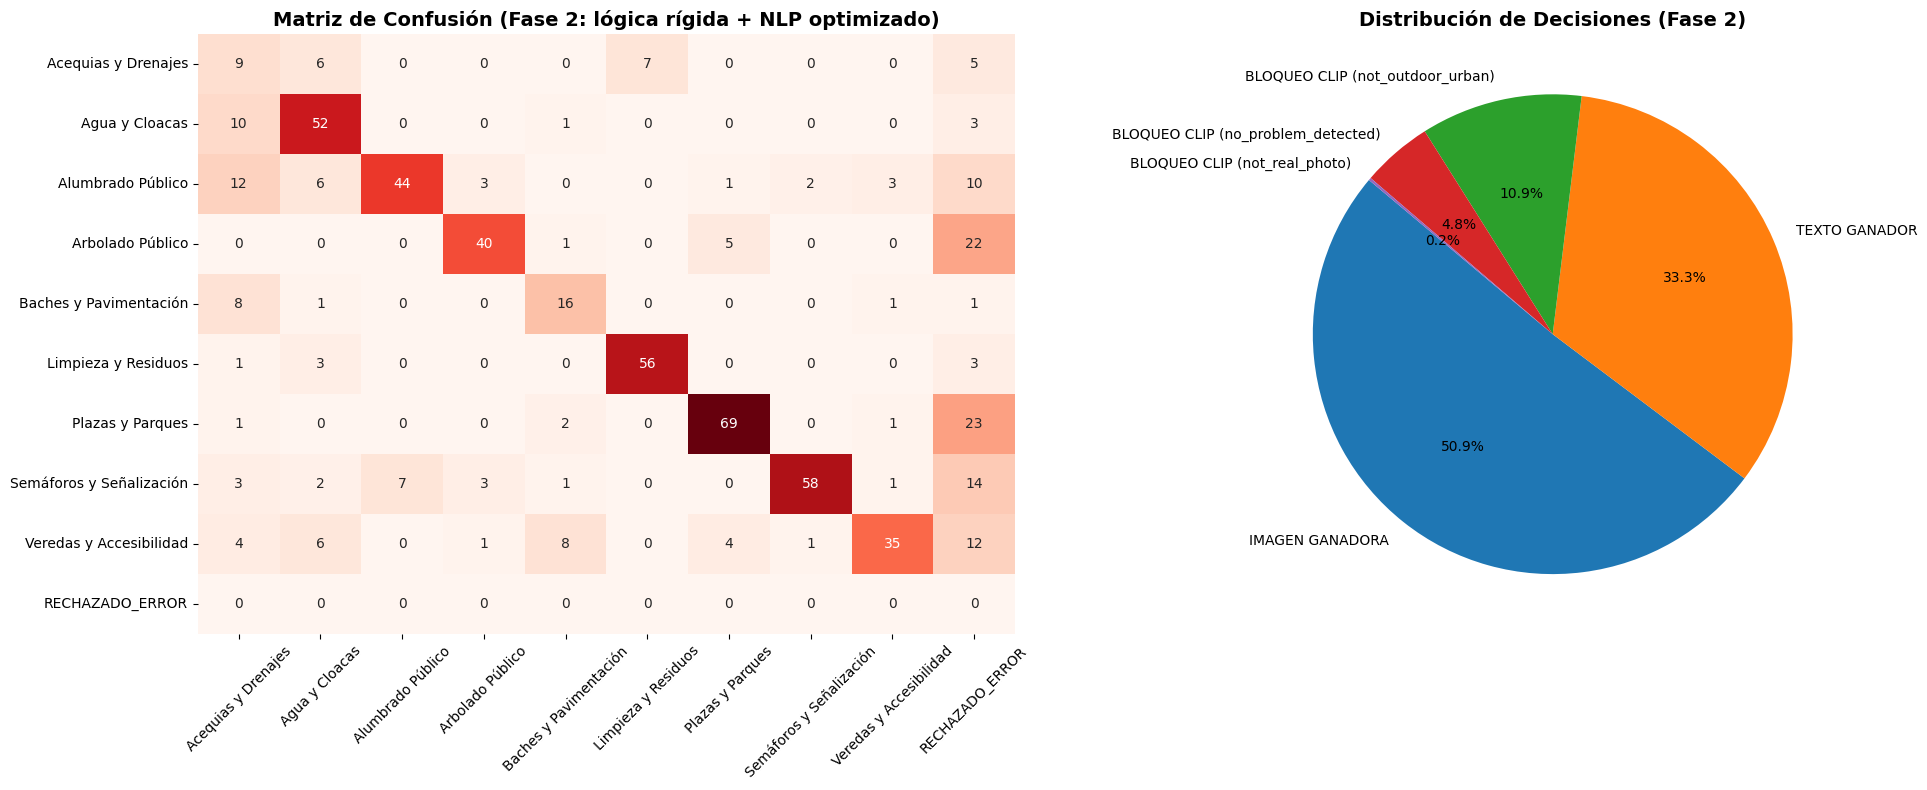

In [11]:
# GRAFICOS
cats = sorted(validos["esperado"].unique())
if "RECHAZADO_ERROR" in validos["prediccion"].values:
    cats.append("RECHAZADO_ERROR")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
cm = confusion_matrix(validos["esperado"], validos["prediccion"], labels=cats)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=cats, yticklabels=cats, ax=axes[0], cbar=False)
axes[0].set_title("Matriz de Confusión (Fase 2: lógica rígida + NLP optimizado)", fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

mecanismos = validos["mecanismo"].value_counts()
axes[1].pie(mecanismos, labels=mecanismos.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title("Distribución de Decisiones (Fase 2)", fontsize=14, fontweight='bold')
plt.tight_layout()
png_path = os.path.join(BASE_DIR, 'resultados_fase2.png')
plt.savefig(png_path, dpi=300, bbox_inches='tight')
print(f'[✓] Gráfico guardado en: {png_path}')
plt.show()

In [12]:
from IPython.display import display
print("\n==============================================")
print(" TABLA DETALLADA DE FALLOS (POR ARCHIVO)")
print("==============================================")
errores = df_res[df_res["acierto"] == False].copy()
display(errores[["archivo", "esperado", "prediccion", "mecanismo"]].sort_values(by="esperado"))


 TABLA DETALLADA DE FALLOS (POR ARCHIVO)


,archivo,esperado,prediccion,mecanismo
0,000034.jpg,Acequias y Drenajes,Limpieza y Residuos,IMAGEN GANADORA
25,000063.jpg,Acequias y Drenajes,Limpieza y Residuos,IMAGEN GANADORA
23,000061.jpg,Acequias y Drenajes,Agua y Cloacas,TEXTO GANADOR
21,000057.jpg,Acequias y Drenajes,Limpieza y Residuos,IMAGEN GANADORA
20,000056.jpg,Acequias y Drenajes,Limpieza y Residuos,TEXTO GANADOR
...,...,...,...,...
659,000017.jpg,Veredas y Accesibilidad,Baches y Pavimentación,TEXTO GANADOR
660,000018.jpg,Veredas y Accesibilidad,RECHAZADO_ERROR,BLOQUEO CLIP (no_problem_detected)
661,000019.jpg,Veredas y Accesibilidad,Plazas y Parques,TEXTO GANADOR
669,000027.jpg,Veredas y Accesibilidad,RECHAZADO_ERROR,BLOQUEO CLIP (no_problem_detected)
